Download ETH/UCY pedestrian trajectory datasets

Explanation (English)
This cell downloads the ETH and UCY pedestrian datasets by cloning a public research repository that hosts the original trajectory files.

In [6]:
import os
import subprocess

RAW_DIR = "data_real/raw"
os.makedirs(RAW_DIR, exist_ok=True)

# Correction : Utilisez l'URL racine du dépôt (se terminant par .git)
repo_url = "https://github.com/abduallahmohamed/Social-STGCNN.git"
target_dir = os.path.join(RAW_DIR, "Social-STGCNN")

if not os.path.exists(target_dir):
    # La commande va maintenant fonctionner car l'URL est correcte
    subprocess.run(["git", "clone", repo_url, target_dir], check=True)
else:
    print("Repository already exists.")

# Vos datasets seront alors disponibles dans :
# os.path.join(target_dir, "datasets")
print("Dataset repository ready at:", target_dir)

Dataset repository ready at: data_real/raw\Social-STGCNN


“Set project paths and verify dataset structure”

Explanation (EN): Define the dataset root folder and quickly verify that each scene directory exists before loading any files.

In [8]:
import os
from pathlib import Path

# Root of the real dataset (based on your screenshot)
DATA_ROOT = Path("data_real") / "raw"

SCENES = ["eth", "hotel", "univ", "zara01", "zara02"]
SPLITS = ["train", "val", "test"]

print("DATA_ROOT:", DATA_ROOT)
print("DATA_ROOT exists:", DATA_ROOT.exists())
print()

for scene in SCENES:
    scene_dir = DATA_ROOT / scene
    print(f"{scene:>6} exists:", scene_dir.exists())


DATA_ROOT: data_real\raw
DATA_ROOT exists: True

   eth exists: True
 hotel exists: True
  univ exists: True
 zara1 exists: True
 zara2 exists: True


“Detect split folders and list available files”

Explanation (EN): Automatically detect whether each scene contains train/val/test folders, then list a few files to confirm the correct structure.

In [9]:
import glob

def list_some_txt_files(folder, n=5):
    files = sorted(glob.glob(str(folder / "*.txt")))
    return files[:n]

for scene in SCENES:
    scene_dir = DATA_ROOT / scene
    print(f"\n=== Scene: {scene} ===")

    # Check if split folders exist
    has_splits = all((scene_dir / sp).exists() for sp in SPLITS)

    if has_splits:
        print("Split structure detected: train/val/test")
        for sp in SPLITS:
            sp_dir = scene_dir / sp
            files = list_some_txt_files(sp_dir, n=3)
            print(f"  {sp}: {len(glob.glob(str(sp_dir/'*.txt')))} files")
            for f in files:
                print("    -", Path(f).name)
    else:
        print("No split folders detected (flat structure). Listing .txt directly:")
        files = list_some_txt_files(scene_dir, n=5)
        print(f"  {len(glob.glob(str(scene_dir/'*.txt')))} files")
        for f in files:
            print("    -", Path(f).name)



=== Scene: eth ===
Split structure detected: train/val/test
  train: 7 files
    - biwi_hotel_train.txt
    - crowds_zara01_train.txt
    - crowds_zara02_train.txt
  val: 7 files
    - biwi_hotel_val.txt
    - crowds_zara01_val.txt
    - crowds_zara02_val.txt
  test: 1 files
    - biwi_eth.txt

=== Scene: hotel ===
Split structure detected: train/val/test
  train: 7 files
    - biwi_eth_train.txt
    - crowds_zara01_train.txt
    - crowds_zara02_train.txt
  val: 7 files
    - biwi_eth_val.txt
    - crowds_zara01_val.txt
    - crowds_zara02_val.txt
  test: 1 files
    - biwi_hotel.txt

=== Scene: univ ===
Split structure detected: train/val/test
  train: 6 files
    - biwi_eth_train.txt
    - biwi_hotel_train.txt
    - crowds_zara01_train.txt
  val: 6 files
    - biwi_eth_val.txt
    - biwi_hotel_val.txt
    - crowds_zara01_val.txt
  test: 2 files
    - students001.txt
    - students003.txt

=== Scene: zara1 ===
Split structure detected: train/val/test
  train: 7 files
    - biwi_eth_t

“Load one trajectory file into a clean dataframe”

Explanation (EN): Load a single ETH/UCY .txt file and convert it into a structured dataframe with columns (frame, pid, x, y).

In [10]:
import pandas as pd
from pathlib import Path

DATA_ROOT = Path("data_real") / "raw"

# Example: ETH train file (change if you want)
sample_path = DATA_ROOT / "eth" / "train" / "biwi_hotel_train.txt"
print("Loading:", sample_path)

df = pd.read_csv(
    sample_path,
    sep=r"\s+",
    header=None,
    names=["frame", "pid", "x", "y"]
)

# Ensure numeric
df = df.astype({"frame": float, "pid": float, "x": float, "y": float})

print("Shape:", df.shape)
df.head(10)


Loading: data_real\raw\eth\train\biwi_hotel_train.txt
Shape: (4946, 4)


,frame,pid,x,y
0,0.0,1.0,1.41,-5.68
1,0.0,2.0,0.51,-6.94
2,0.0,3.0,2.30,-4.59
3,0.0,4.0,2.74,-2.50
4,0.0,5.0,-1.59,0.93
5,0.0,6.0,-1.72,1.32
6,0.0,7.0,-2.45,2.26
7,0.0,8.0,-1.45,-0.76
8,0.0,9.0,1.16,-8.54
9,0.0,10.0,-0.11,-9.90


“Quick sanity checks and basic stats”

Explanation (EN): Verify that frames are ordered and check how many pedestrians and frames exist in the file.

In [11]:
print("Frames range:", df["frame"].min(), "->", df["frame"].max())
print("Num unique pedestrians:", df["pid"].nunique())
print("Num unique frames:", df["frame"].nunique())

# Check if frames are spaced regularly (often 10.0 steps in these files)
frame_diffs = pd.Series(sorted(df["frame"].unique())).diff().dropna()
print("Most common frame step:", frame_diffs.value_counts().head(3))


Frames range: 0.0 -> 14390.0
Num unique pedestrians: 311
Num unique frames: 934
Most common frame step: 10.0     911
60.0       3
420.0      3
Name: count, dtype: int64


“Build per-pedestrian trajectories (sorted by time)”

Explanation (EN): Group positions by pedestrian ID to obtain individual trajectories ordered by frame.

In [12]:
# Sort by pedestrian and time
df_sorted = df.sort_values(["pid", "frame"]).reset_index(drop=True)

traj_by_pid = {}
for pid, g in df_sorted.groupby("pid"):
    traj_by_pid[pid] = g[["frame", "x", "y"]].to_numpy()

print("Example pedestrian IDs:", list(traj_by_pid.keys())[:5])
pid0 = list(traj_by_pid.keys())[0]
print("Trajectory shape for one pedestrian:", traj_by_pid[pid0].shape)
traj_by_pid[pid0][:10]


Example pedestrian IDs: [1.0, 2.0, 3.0, 4.0, 5.0]
Trajectory shape for one pedestrian: (2, 3)


array([[ 0.  ,  1.41, -5.68],
       [10.  ,  1.28, -6.35]])

“Sliding window: create supervised (X, Y) pairs”

Explanation (EN): Convert each pedestrian trajectory into supervised samples using a 10-step history window to predict the next position.

In [13]:
import numpy as np

OBS_LEN = 10  # input length

X_list, Y_list = [], []

for pid, traj in traj_by_pid.items():
    # traj columns: frame, x, y
    coords = traj[:, 1:3]  # keep only x,y

    if len(coords) <= OBS_LEN:
        continue

    for t in range(len(coords) - OBS_LEN):
        x_seq = coords[t:t+OBS_LEN]        # shape (10,2)
        y_next = coords[t+OBS_LEN]         # shape (2,)
        X_list.append(x_seq)
        Y_list.append(y_next)

X = np.stack(X_list)  # (N,10,2)
Y = np.stack(Y_list)  # (N,2)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Example X[0]:\n", X[0])
print("Example Y[0]:\n", Y[0])


X shape: (2250, 10, 2)
Y shape: (2250, 2)
Example X[0]:
 [[ 2.3  -4.59]
 [ 1.94 -4.12]
 [ 1.53 -3.49]
 [ 1.14 -2.99]
 [ 0.84 -2.46]
 [ 0.45 -2.  ]
 [ 0.17 -1.52]
 [-0.1  -0.97]
 [-0.34 -0.39]
 [-0.55  0.19]]
Example Y[0]:
 [-0.76  0.73]


“Explain clearly (for defense): what are X and Y?”

Explanation (EN): Provide a human-readable explanation of how one training sample is constructed from raw trajectories.

In [14]:
idx = 0
print("One supervised sample:")
print("- X is the past 10 positions (x,y):")
print(X[idx])
print("\n- Y is the next position after these 10 points:")
print(Y[idx])


One supervised sample:
- X is the past 10 positions (x,y):
[[ 2.3  -4.59]
 [ 1.94 -4.12]
 [ 1.53 -3.49]
 [ 1.14 -2.99]
 [ 0.84 -2.46]
 [ 0.45 -2.  ]
 [ 0.17 -1.52]
 [-0.1  -0.97]
 [-0.34 -0.39]
 [-0.55  0.19]]

- Y is the next position after these 10 points:
[-0.76  0.73]


“Plot one trajectory + highlight the sliding window”

Explanation (EN): Visualize a pedestrian path, highlight the 10-point input window, and show the target point.

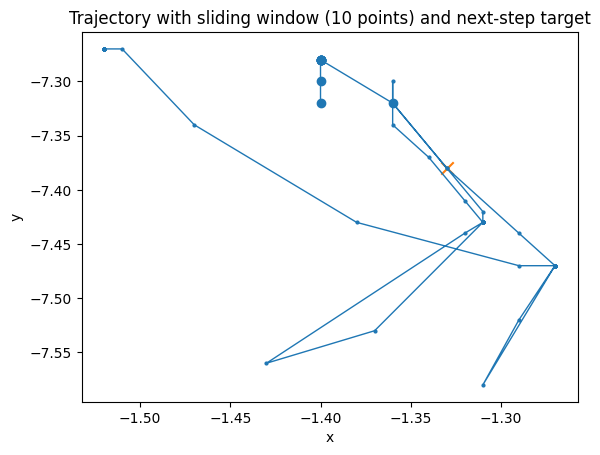

In [15]:
import matplotlib.pyplot as plt

# pick a pedestrian with enough points
pid = max(traj_by_pid.keys(), key=lambda p: len(traj_by_pid[p]))
coords = traj_by_pid[pid][:, 1:3]  # (T,2)

t0 = 0
window = coords[t0:t0+OBS_LEN]
target = coords[t0+OBS_LEN]

plt.figure()
plt.plot(coords[:,0], coords[:,1], marker="o", linewidth=1, markersize=2)
plt.scatter(window[:,0], window[:,1], marker="o")
plt.scatter([target[0]], [target[1]], marker="x", s=80)
plt.title("Trajectory with sliding window (10 points) and next-step target")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


“Animated visualization of sliding window trajectory prediction”

Explanation (EN)

This cell creates an animated visualization showing how a sliding window of 10 past positions is used to predict the next position in a pedestrian trajectory.

In [16]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Use one pedestrian trajectory
pid = max(traj_by_pid.keys(), key=lambda p: len(traj_by_pid[p]))
coords = traj_by_pid[pid][:, 1:3]  # (T,2)

OBS_LEN = 10
T = len(coords)

fig, ax = plt.subplots()
ax.set_title("Sliding Window Trajectory Prediction")
ax.set_xlabel("x")
ax.set_ylabel("y")

# Plot full trajectory (background)
ax.plot(coords[:,0], coords[:,1], color="lightgray", linewidth=1)

window_scatter = ax.scatter([], [], color="blue", label="Input window (10 points)")
target_scatter = ax.scatter([], [], color="red", marker="x", s=80, label="Target (next point)")
ax.legend()

def update(frame):
    if frame + OBS_LEN >= T:
        return window_scatter, target_scatter

    window = coords[frame:frame+OBS_LEN]
    target = coords[frame+OBS_LEN]

    window_scatter.set_offsets(window)
    target_scatter.set_offsets([target])

    return window_scatter, target_scatter

ani = animation.FuncAnimation(
    fig,
    update,
    frames=T-OBS_LEN,
    interval=300,
    blit=True
)

# Save GIF
ani.save("sliding_window_prediction.gif", writer="pillow")
plt.close()

print("GIF saved as sliding_window_prediction.gif")


GIF saved as sliding_window_prediction.gif
